## Crop Recommendation System Using Machine Learning

This notebook develops a machine learning model to recommend suitable crops based on soil nutrients and weather conditions. The dataset is analyzed, preprocessed, and used to train different machine learning algorithms. The performance of the models is then compared to identify the best one.

## 1. Importing Required Libraries

The required Python libraries are imported for data analysis, visualization, and machine learning. These libraries help in loading the dataset, understanding the data, creating graphs, and building prediction models.

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

## 2. Loading the Dataset

The crop recommendation dataset is loaded using Pandas. It contains information about soil nutrients, weather conditions, and the corresponding crop labels that will be used for prediction.

In [ ]:
df = pd.read_csv('/content/Crop_recommendation.csv')

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

## 3. Displaying the Dataset

The first few rows of the dataset are displayed to understand its structure, features, and target variable.

In [ ]:
df.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


## 4. Understanding the Dataset

The dataset is examined to understand its dimensions, data types, and statistical summary before further analysis.

In [ ]:
df.shape

(2200, 8)

In [ ]:
df.info()

In [ ]:
df.describe()

## 5. Data Quality Check

The dataset is checked for missing and duplicate values to ensure that it is clean before performing further analysis and model training.

In [ ]:
df.isnull().sum()

,0
N,0
P,0
K,0
temperature,0
humidity,0
ph,0
rainfall,0
label,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df['label'].value_counts()

In [ ]:
df.columns

Index(['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label'], dtype='object')

### Observation

No missing or duplicate values were found in the dataset. This shows that the dataset is clean and ready for further analysis and model development.

## 6. Exploratory Data Analysis (EDA)

Exploratory Data Analysis is performed to understand the distribution of the data, identify relationships between features, and gain useful insights before training the machine learning models.

### 6.1 Distribution of Crop Classes

This graph shows the number of samples available for each crop in the dataset.

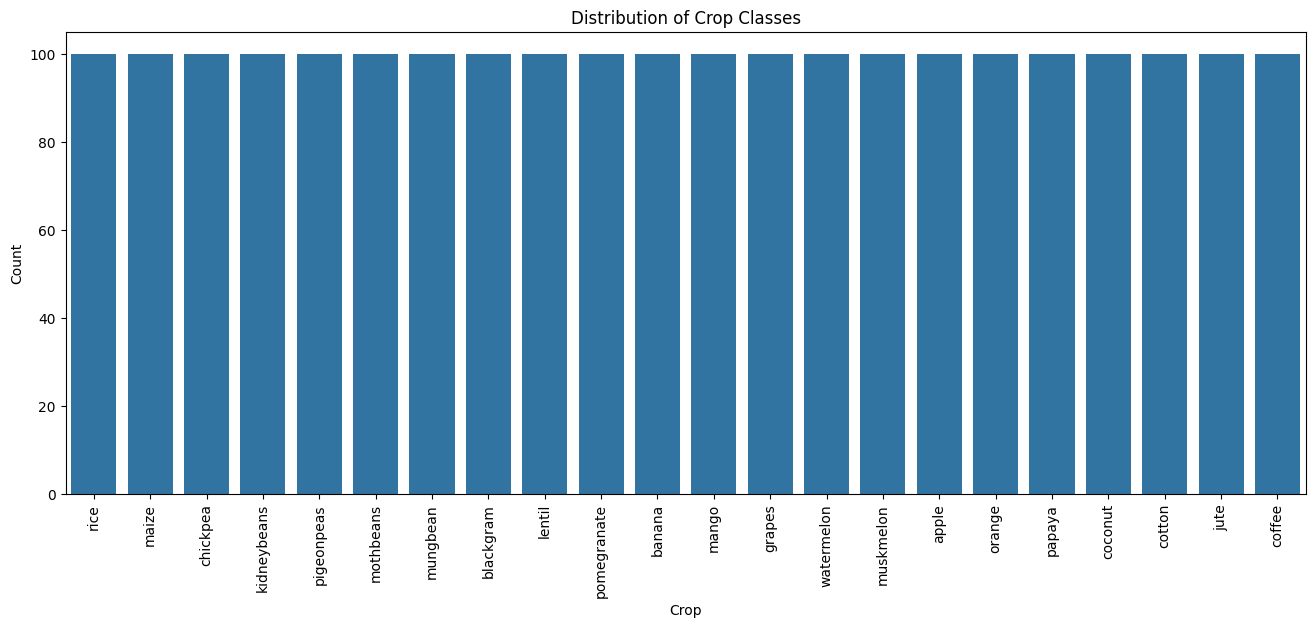

In [ ]:
plt.figure(figsize=(16,6))

sns.countplot(x='label', data=df)

plt.xticks(rotation=90)

plt.title("Distribution of Crop Classes")

plt.xlabel("Crop")

plt.ylabel("Count")

plt.show()

### Observation

The graph shows that all crop classes have an equal number of samples (100 each). This indicates that the dataset is balanced, which helps the machine learning models learn all crop classes equally and reduces prediction bias.

### 6.2 Correlation Heatmap

A correlation heatmap is used to visualize the relationship between the numerical features in the dataset. Correlation values range from -1 to 1, where values closer to 1 indicate a strong positive relationship and values closer to -1 indicate a strong negative relationship.

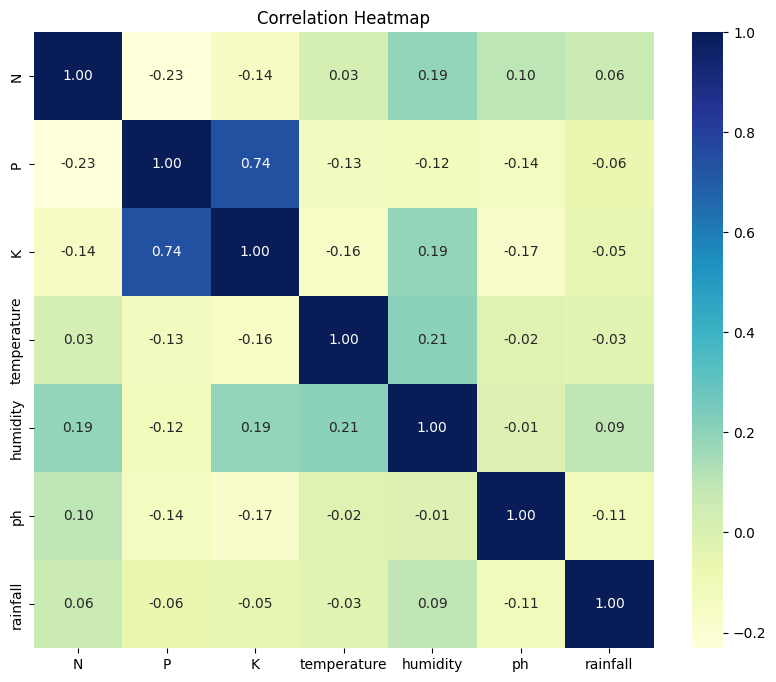

In [ ]:
plt.figure(figsize=(10,8))

correlation = df.drop('label', axis=1).corr()

sns.heatmap(correlation,
            annot=True,
            cmap='YlGnBu',
            fmt=".2f")

plt.title("Correlation Heatmap")

plt.show()

### Observation

The heatmap shows that most features have weak to moderate correlations, indicating that they provide different information for crop recommendation. A stronger positive correlation is observed between phosphorus (P) and potassium (K), while the remaining features show relatively low correlation with each other.

### 6.3 Distribution of Numerical Features

Histograms are used to visualize the distribution of each numerical feature in the dataset. They help identify the range and spread of the data.

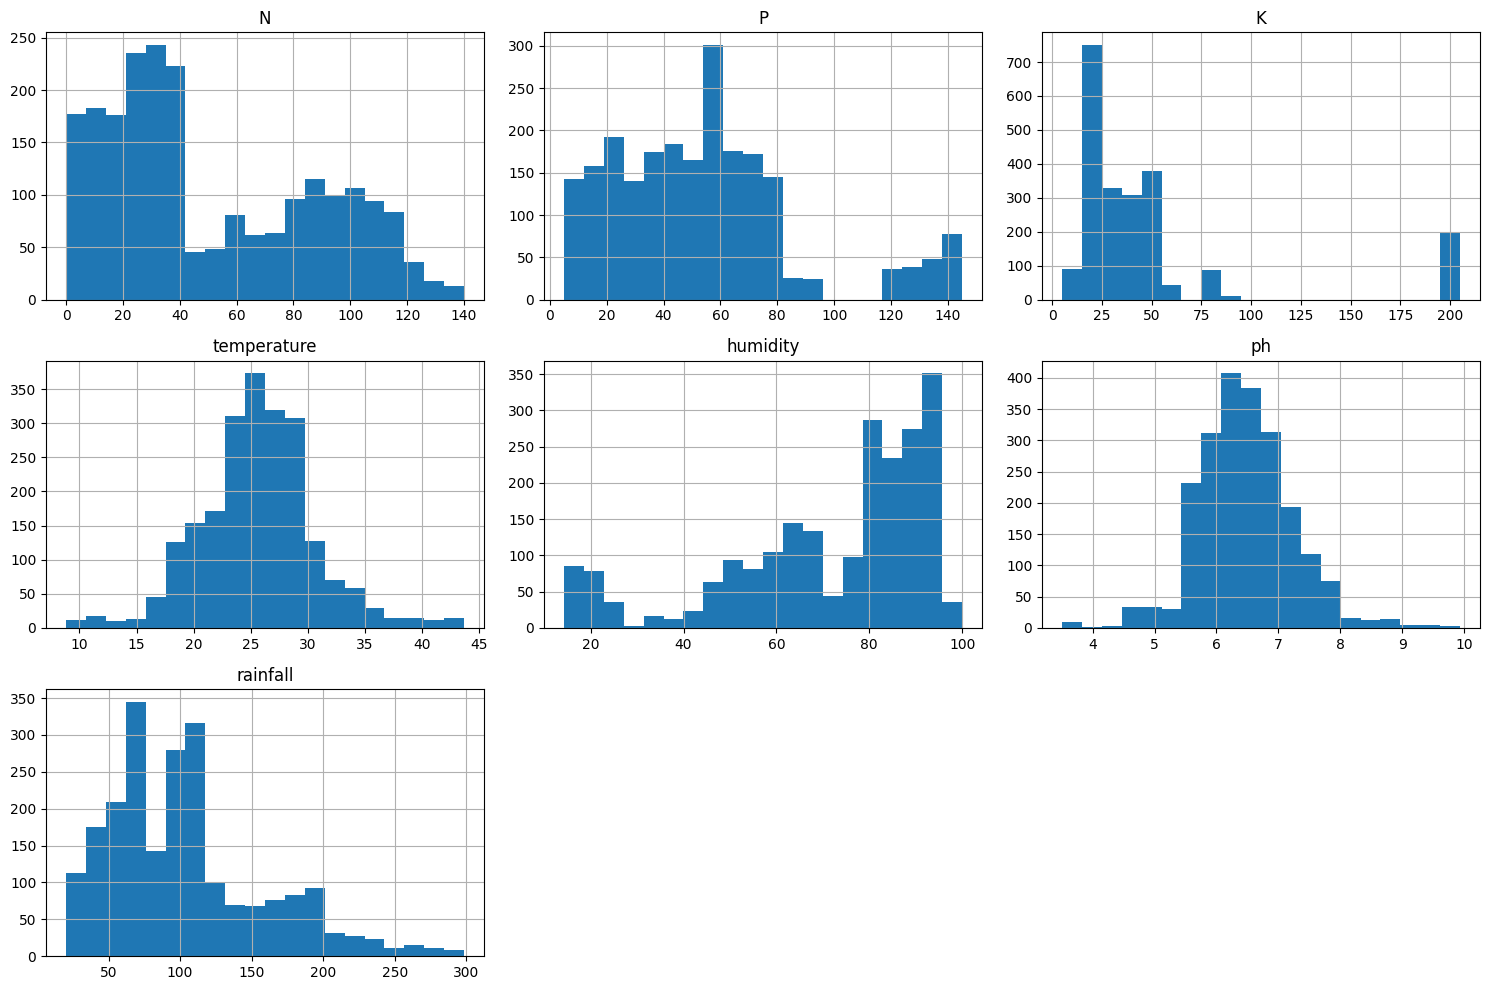

In [ ]:
df.hist(figsize=(15,10), bins=20)

plt.tight_layout()

plt.show()

### Observation

The histograms show that the numerical features have different distributions and value ranges. Some features, such as pH and temperature, are distributed more evenly, while others like potassium (K) and rainfall show greater variation. These differences provide useful information for distinguishing between different crop types.

### 6.4 Boxplots of Numerical Features

Boxplots are used to examine the spread of each numerical feature and identify the presence of any outliers in the dataset.

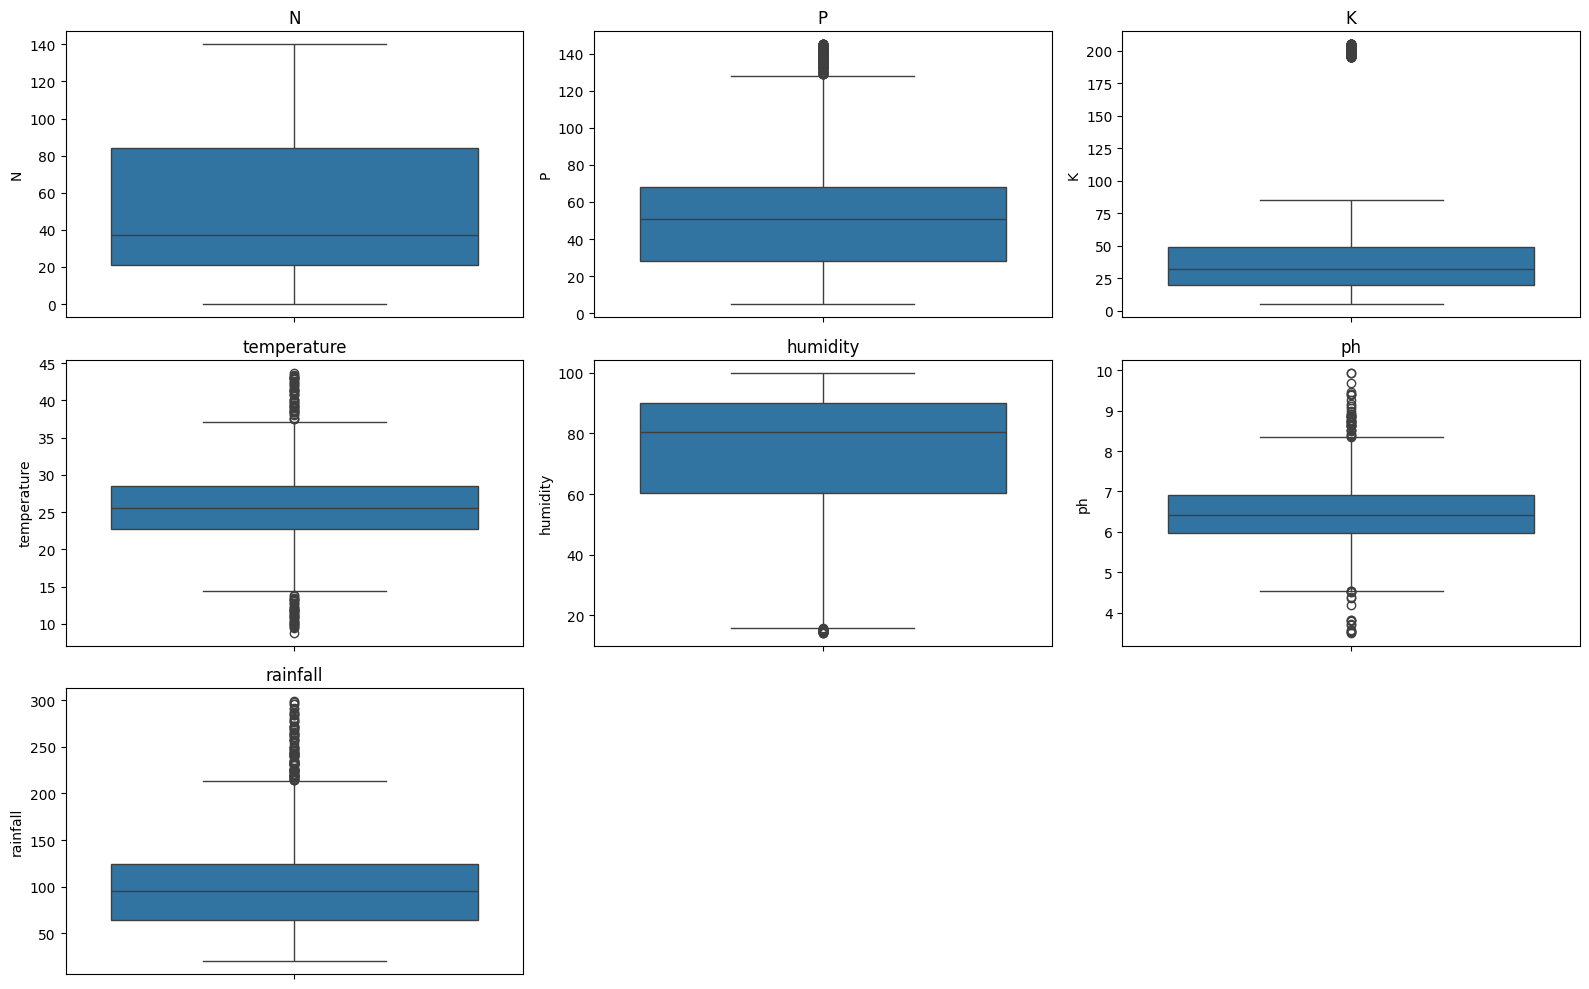

In [ ]:
plt.figure(figsize=(16,10))

for i, column in enumerate(df.columns[:-1], 1):
    plt.subplot(3,3,i)
    sns.boxplot(y=df[column])
    plt.title(column)

plt.tight_layout()
plt.show()

### Observation

The boxplots show that some features contain outliers, particularly in potassium (K), rainfall, temperature, and pH. These values are expected because different crops require different soil and weather conditions. Therefore, these observations are likely to represent natural variation rather than errors in the dataset.

## 7. Data Preprocessing

Data preprocessing is an important step before model training. It involves separating the input features and target variable, converting categorical values into numerical form, and preparing the dataset for machine learning algorithms.

### 7.1 Feature Selection

The input features (X) and target variable (y) are separated. The input features contain soil nutrients and weather parameters, while the target variable contains the crop labels.

In [ ]:
X = df.drop('label', axis=1)
y = df['label']

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (2200, 7)
Target Shape: (2200,)


### Observation

The dataset contains seven input features and one target variable. These features will be used to train the machine learning models for crop prediction.

### 7.2 Label Encoding

The target labels are converted into numerical values using Label Encoder. Machine learning algorithms work with numerical data, so encoding is required before training the models.

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y = le.fit_transform(y)

print(y[:10])

[20 20 20 20 20 20 20 20 20 20]


### Observation

The crop names have been converted into numerical labels. This allows the machine learning algorithms to process the target variable correctly.

### 7.3 Train-Test Split

The dataset is divided into training and testing sets. The training set is used to train the machine learning models, while the testing set is used to evaluate their performance on unseen data.

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Features:", X_train.shape)
print("Testing Features :", X_test.shape)
print("Training Labels  :", y_train.shape)
print("Testing Labels   :", y_test.shape)

Training Features: (1760, 7)
Testing Features : (440, 7)
Training Labels  : (1760,)
Testing Labels   : (440,)


### Observation

The dataset was divided into 80% training data and 20% testing data. The training data will be used to build the models, while the testing data will be used to evaluate their performance.

### 7.4 Feature Scaling

Feature scaling is applied using StandardScaler to bring all numerical features to a similar scale. This helps improve the performance of machine learning algorithms that are sensitive to differences in feature values.

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training data shape:", X_train_scaled.shape)
print("Testing data shape :", X_test_scaled.shape)

Training data shape: (1760, 7)
Testing data shape : (440, 7)


### Observation

The features have been standardized to a common scale. This helps machine learning algorithms such as Logistic Regression, KNN, and SVM learn more effectively while keeping the evaluation fair.

# 8. Model Training

In this section, different machine learning algorithms are trained and evaluated on the crop recommendation dataset. The performance of each model is compared to identify the most suitable algorithm for crop prediction.

## 8.1 Logistic Regression

Logistic Regression is a supervised machine learning algorithm commonly used for classification problems. It serves as a baseline model for comparing the performance of other algorithms.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train_scaled, y_train)

y_pred_lr = lr_model.predict(X_test_scaled)

lr_accuracy = accuracy_score(y_test, y_pred_lr)

print("Accuracy:", round(lr_accuracy*100,2),"%")

Accuracy: 96.36 %


In [ ]:
results = []

results.append(["Logistic Regression", lr_accuracy])

In [ ]:
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        23
           1       1.00      1.00      1.00        21
           2       0.90      0.95      0.93        20
           3       1.00      1.00      1.00        26
           4       1.00      1.00      1.00        27
           5       0.94      1.00      0.97        17
           6       0.94      1.00      0.97        17
           7       1.00      1.00      1.00        14
           8       0.83      0.87      0.85        23
           9       0.95      0.95      0.95        20
          10       0.85      1.00      0.92        11
          11       1.00      0.95      0.98        21
          12       1.00      1.00      1.00        19
          13       1.00      0.92      0.96        24
          14       1.00      1.00      1.00        19
          15       1.00      1.00      1.00        17
          16       1.00      1.00      1.00        14
          17       0.96    

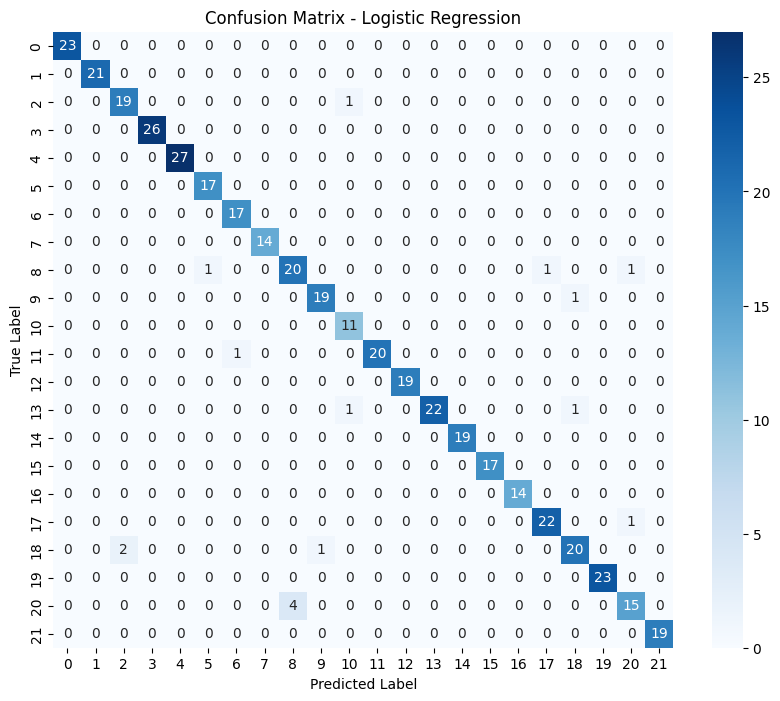

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

### Observation

The Logistic Regression model achieved good classification performance on the testing dataset. The confusion matrix shows that most crop classes were predicted correctly, although a few misclassifications were observed.

## 8.2 Decision Tree

Decision Tree is a supervised machine learning algorithm that classifies data by creating a tree-like structure of decision rules. It is simple to understand and can capture complex relationships between features without requiring feature scaling.

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

dt_accuracy = accuracy_score(y_test, y_pred_dt)

print("Accuracy:", round(dt_accuracy*100,2), "%")

Accuracy: 98.64 %


In [ ]:
results.append(["Decision Tree", dt_accuracy])

In [ ]:
print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        23
           1       1.00      1.00      1.00        21
           2       0.95      1.00      0.98        20
           3       1.00      1.00      1.00        26
           4       0.96      1.00      0.98        27
           5       1.00      1.00      1.00        17
           6       1.00      1.00      1.00        17
           7       1.00      1.00      1.00        14
           8       0.92      0.96      0.94        23
           9       1.00      1.00      1.00        20
          10       0.92      1.00      0.96        11
          11       1.00      0.95      0.98        21
          12       1.00      1.00      1.00        19
          13       1.00      0.92      0.96        24
          14       1.00      1.00      1.00        19
          15       1.00      1.00      1.00        17
          16       1.00      1.00      1.00        14
          17       1.00    

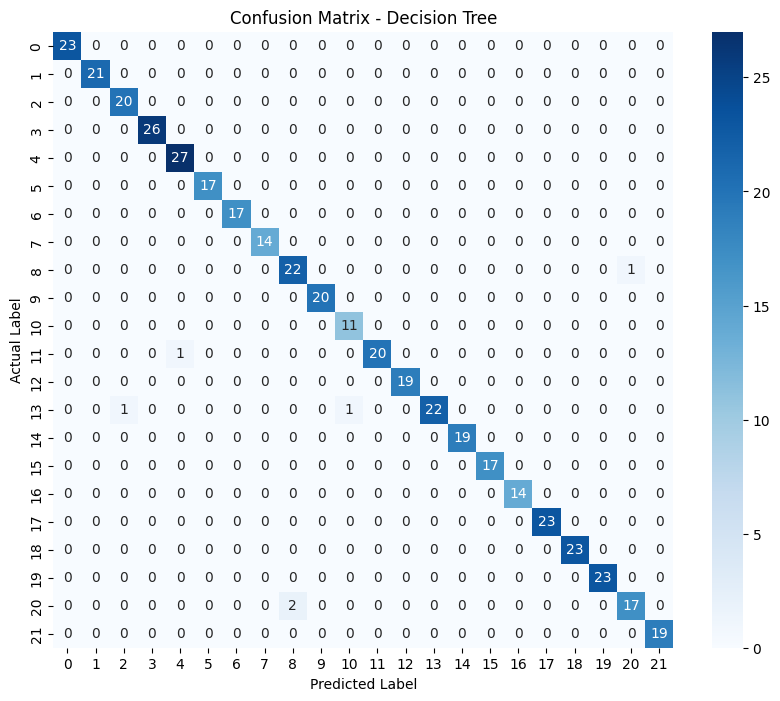

In [ ]:
cm = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(10,8))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.title("Confusion Matrix - Decision Tree")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

### Observation

The Decision Tree model was trained successfully and evaluated on the testing dataset. It was able to classify most crop types correctly and will be compared with the other machine learning models based on its overall accuracy.

## 8.3 Random Forest

Random Forest is an ensemble learning algorithm that combines multiple decision trees to improve prediction accuracy and reduce overfitting. It is widely used because of its high performance and robustness.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

rf_accuracy = accuracy_score(y_test, y_pred_rf)

print("Accuracy:", round(rf_accuracy*100,2), "%")

Accuracy: 99.32 %


In [ ]:
results.append(["Random Forest", rf_accuracy])

In [ ]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        23
           1       1.00      1.00      1.00        21
           2       1.00      1.00      1.00        20
           3       1.00      1.00      1.00        26
           4       1.00      1.00      1.00        27
           5       1.00      1.00      1.00        17
           6       1.00      1.00      1.00        17
           7       1.00      1.00      1.00        14
           8       0.92      1.00      0.96        23
           9       1.00      1.00      1.00        20
          10       0.92      1.00      0.96        11
          11       1.00      1.00      1.00        21
          12       1.00      1.00      1.00        19
          13       1.00      0.96      0.98        24
          14       1.00      1.00      1.00        19
          15       1.00      1.00      1.00        17
          16       1.00      1.00      1.00        14
          17       1.00    

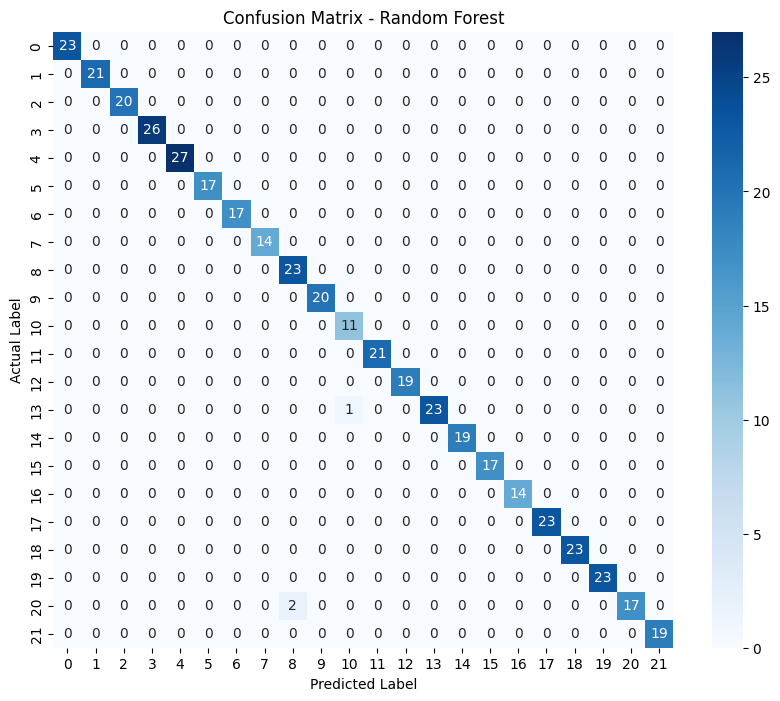

In [ ]:
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(10,8))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

### Observation

The Random Forest model achieved an accuracy of 99.32%, making it the best-performing model so far. The confusion matrix shows very few misclassifications, indicating that the model can accurately recommend crops based on the given soil and weather parameters.

## 8.4 K-Nearest Neighbors (KNN)

K-Nearest Neighbors (KNN) is a supervised machine learning algorithm that classifies a sample based on the majority class of its nearest neighbors. Since it uses distance to make predictions, feature scaling is required before training the model.

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=5)

knn_model.fit(X_train_scaled, y_train)

y_pred_knn = knn_model.predict(X_test_scaled)

knn_accuracy = accuracy_score(y_test, y_pred_knn)

print("Accuracy:", round(knn_accuracy*100,2), "%")

Accuracy: 95.68 %


In [ ]:
results.append(["KNN", knn_accuracy])

In [ ]:
print(classification_report(y_test, y_pred_knn))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        23
           1       1.00      1.00      1.00        21
           2       0.95      0.95      0.95        20
           3       1.00      1.00      1.00        26
           4       1.00      1.00      1.00        27
           5       0.94      1.00      0.97        17
           6       0.89      1.00      0.94        17
           7       1.00      1.00      1.00        14
           8       0.81      0.96      0.88        23
           9       0.91      1.00      0.95        20
          10       0.69      1.00      0.81        11
          11       1.00      0.90      0.95        21
          12       0.90      1.00      0.95        19
          13       1.00      0.83      0.91        24
          14       1.00      1.00      1.00        19
          15       1.00      1.00      1.00        17
          16       1.00      1.00      1.00        14
          17       1.00    

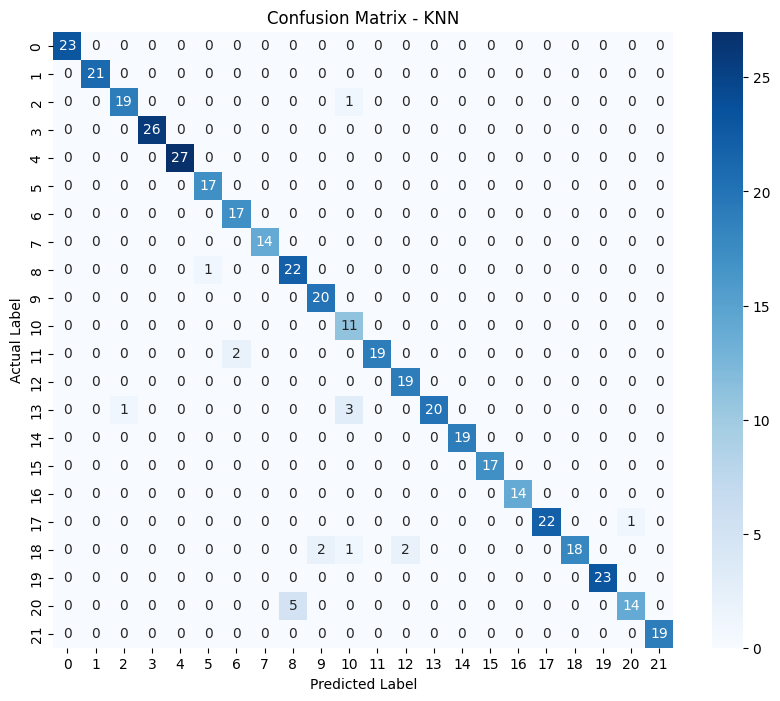

In [ ]:
cm = confusion_matrix(y_test, y_pred_knn)

plt.figure(figsize=(10,8))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.title("Confusion Matrix - KNN")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

### Observation

The KNN model achieved an accuracy of 95.68% on the testing dataset. Although it performed well, its accuracy was lower than the Decision Tree and Random Forest models. This indicates that KNN was less effective for this crop recommendation dataset.

## 8.5 Naive Bayes

Naive Bayes is a probabilistic machine learning algorithm based on Bayes' theorem. It assumes that all features are independent of each other, making it simple, fast, and effective for many classification problems.

In [ ]:
from sklearn.naive_bayes import GaussianNB

nb_model = GaussianNB()

nb_model.fit(X_train, y_train)

y_pred_nb = nb_model.predict(X_test)

nb_accuracy = accuracy_score(y_test, y_pred_nb)

print("Accuracy:", round(nb_accuracy*100,2), "%")

Accuracy: 99.55 %


In [ ]:
results.append(["Naive Bayes", nb_accuracy])

In [ ]:
print(classification_report(y_test, y_pred_nb))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        23
           1       1.00      1.00      1.00        21
           2       1.00      1.00      1.00        20
           3       1.00      1.00      1.00        26
           4       1.00      1.00      1.00        27
           5       1.00      1.00      1.00        17
           6       1.00      1.00      1.00        17
           7       1.00      1.00      1.00        14
           8       0.92      1.00      0.96        23
           9       1.00      1.00      1.00        20
          10       1.00      1.00      1.00        11
          11       1.00      1.00      1.00        21
          12       1.00      1.00      1.00        19
          13       1.00      1.00      1.00        24
          14       1.00      1.00      1.00        19
          15       1.00      1.00      1.00        17
          16       1.00      1.00      1.00        14
          17       1.00    

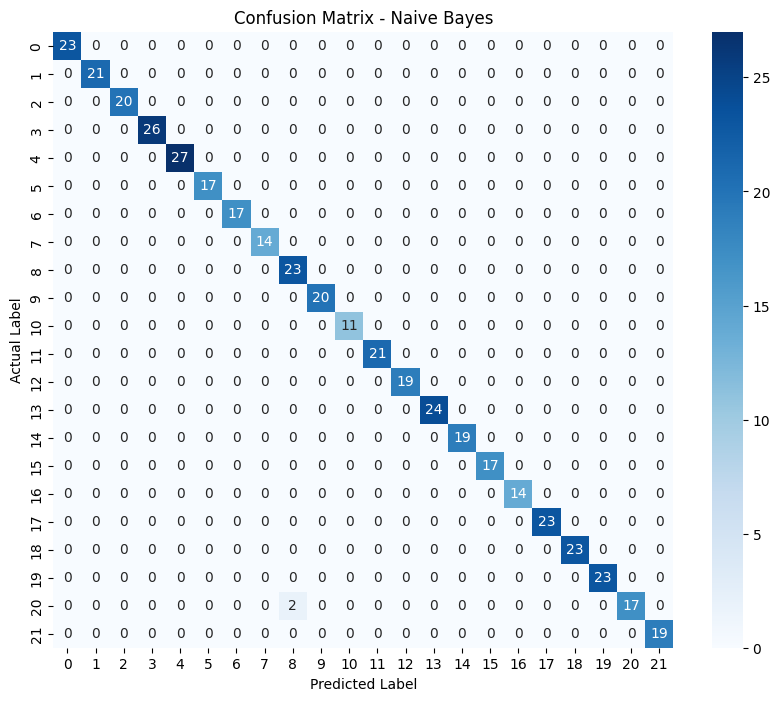

In [ ]:
cm = confusion_matrix(y_test, y_pred_nb)

plt.figure(figsize=(10,8))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.title("Confusion Matrix - Naive Bayes")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

### Observation

The Naive Bayes model achieved an accuracy of 99.55%, making it the best-performing model so far. It classified almost all crop types correctly and showed excellent performance on the testing dataset.

## 8.6 Support Vector Machine (SVM)

Support Vector Machine (SVM) is a supervised machine learning algorithm used for classification tasks. It works by finding the optimal boundary that separates different classes. Since SVM is sensitive to feature scales, the standardised dataset is used for training.

In [ ]:
from sklearn.svm import SVC

svm_model = SVC(kernel='rbf', random_state=42)

svm_model.fit(X_train_scaled, y_train)

y_pred_svm = svm_model.predict(X_test_scaled)

svm_accuracy = accuracy_score(y_test, y_pred_svm)

print("Accuracy:", round(svm_accuracy*100,2), "%")

Accuracy: 96.82 %


In [ ]:
results.append(["SVM", svm_accuracy])

In [ ]:
print(classification_report(y_test, y_pred_svm))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        23
           1       1.00      1.00      1.00        21
           2       1.00      0.95      0.97        20
           3       1.00      1.00      1.00        26
           4       1.00      1.00      1.00        27
           5       0.94      1.00      0.97        17
           6       0.94      1.00      0.97        17
           7       1.00      1.00      1.00        14
           8       0.78      0.91      0.84        23
           9       0.91      1.00      0.95        20
          10       0.79      1.00      0.88        11
          11       1.00      0.95      0.98        21
          12       1.00      1.00      1.00        19
          13       1.00      0.92      0.96        24
          14       1.00      1.00      1.00        19
          15       1.00      1.00      1.00        17
          16       1.00      1.00      1.00        14
          17       1.00    

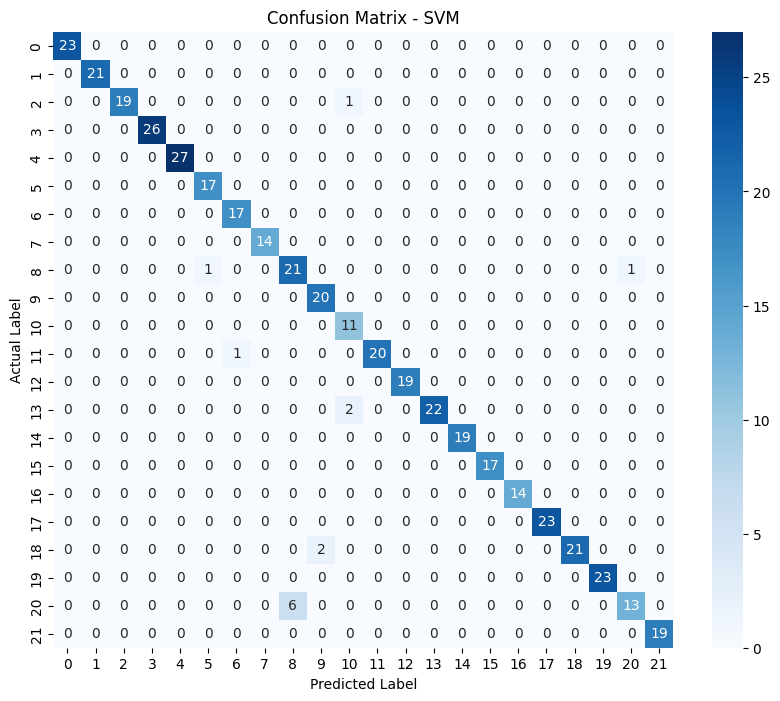

In [ ]:
cm = confusion_matrix(y_test, y_pred_svm)

plt.figure(figsize=(10,8))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.title("Confusion Matrix - SVM")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

### Observation

The SVM model achieved an accuracy of 96.82% on the testing dataset. Although it performed well, its accuracy was lower than the Naive Bayes, Random Forest, and Decision Tree models for this dataset.

## 8.7 XGBoost

XGBoost is an advanced ensemble learning algorithm based on gradient boosting. It builds multiple decision trees sequentially to improve prediction accuracy and is widely used for classification problems due to its speed and high performance.

In [ ]:
!pip install xgboost

In [ ]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    objective='multi:softmax',
    num_class=len(np.unique(y)),
    random_state=42,
    eval_metric='mlogloss'
)

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)

xgb_accuracy = accuracy_score(y_test, y_pred_xgb)

print("Accuracy:", round(xgb_accuracy*100,2), "%")

Accuracy: 98.64 %


In [ ]:
results.append(["XGBoost", xgb_accuracy])

In [ ]:
print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        23
           1       1.00      1.00      1.00        21
           2       0.95      1.00      0.98        20
           3       1.00      1.00      1.00        26
           4       1.00      1.00      1.00        27
           5       1.00      1.00      1.00        17
           6       0.94      1.00      0.97        17
           7       1.00      1.00      1.00        14
           8       0.92      1.00      0.96        23
           9       1.00      1.00      1.00        20
          10       0.92      1.00      0.96        11
          11       1.00      0.95      0.98        21
          12       0.95      1.00      0.97        19
          13       1.00      0.96      0.98        24
          14       1.00      1.00      1.00        19
          15       1.00      1.00      1.00        17
          16       1.00      1.00      1.00        14
          17       1.00    

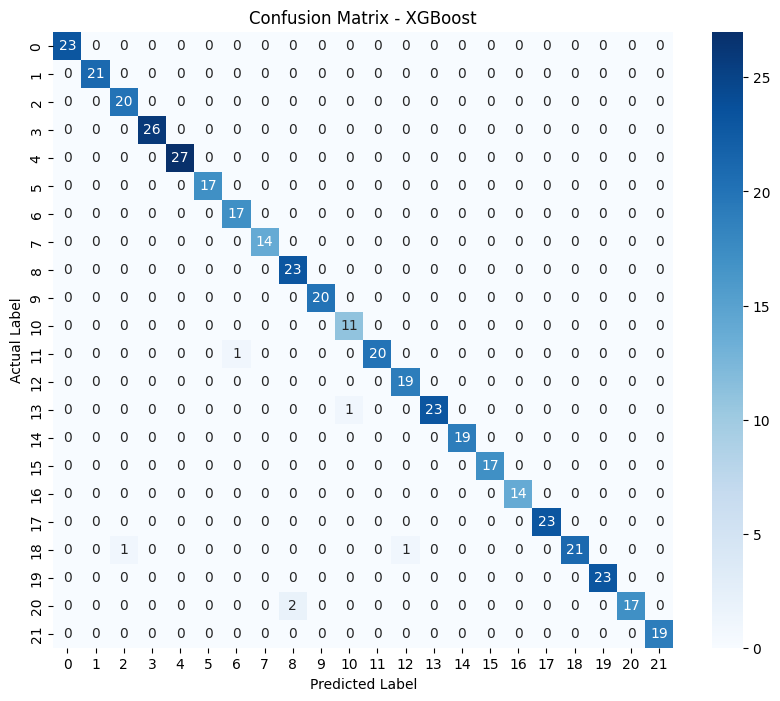

In [ ]:
cm = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(10,8))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.title("Confusion Matrix - XGBoost")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

### Observation

The XGBoost model achieved an accuracy of **98.64%** on the testing dataset. It performed well and produced reliable predictions, but its accuracy was slightly lower than the Naive Bayes and Random Forest models.

# 9. Model Comparison

The performance of all trained machine learning models is compared using their accuracy scores. This comparison helps identify the most suitable model for crop recommendation.

In [ ]:
results_df = pd.DataFrame(results, columns=['Model', 'Accuracy'])

results_df['Accuracy'] = results_df['Accuracy'] * 100

results_df = results_df.sort_values(by='Accuracy', ascending=False)

results_df

,Model,Accuracy
4,Naive Bayes,99.545455
2,Random Forest,99.318182
1,Decision Tree,98.636364
6,XGBoost,98.636364
5,SVM,96.818182
0,Logistic Regression,96.363636
3,KNN,95.681818


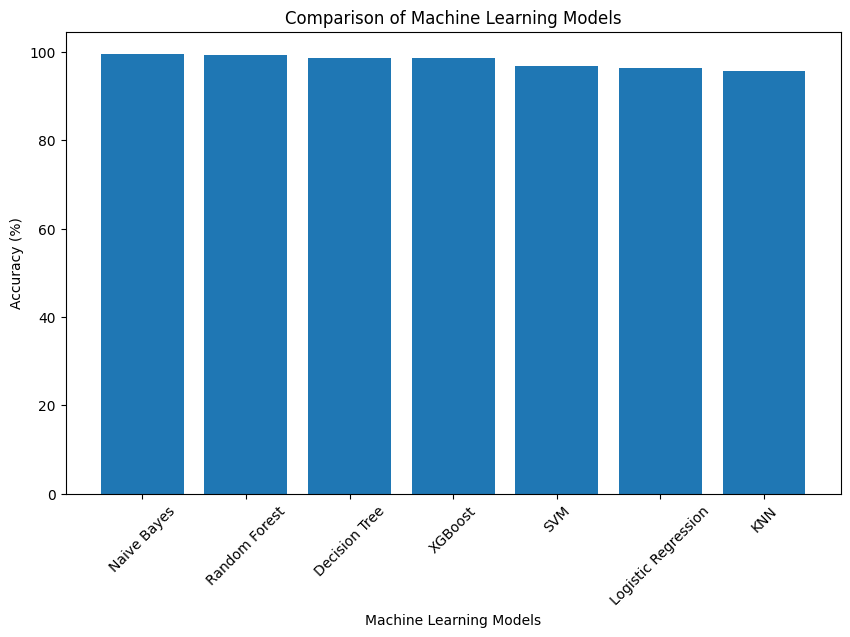

In [ ]:
plt.figure(figsize=(10,6))

plt.bar(results_df['Model'], results_df['Accuracy'])

plt.xticks(rotation=45)

plt.xlabel("Machine Learning Models")
plt.ylabel("Accuracy (%)")
plt.title("Comparison of Machine Learning Models")

plt.show()

In [ ]:
best_model = results_df.iloc[0]

print("Best Model :", best_model['Model'])
print("Accuracy   :", round(best_model['Accuracy'],2), "%")

Best Model : Naive Bayes
Accuracy   : 99.55 %


### Observation

Among all the machine learning models, Naive Bayes achieved the highest accuracy of **99.55%**, followed closely by Random Forest with **99.32%**. Therefore, Naive Bayes was selected as the final model for the crop recommendation system.

# 10. Saving the Best Model

The best-performing model is saved using Joblib so that it can be loaded later in the Streamlit application without retraining.

In [ ]:
import joblib

joblib.dump(nb_model, "crop_recommendation_model.pkl")
joblib.dump(le, "label_encoder.pkl")

print("Model saved successfully.")

Model saved successfully.


# 11. Conclusion

Different machine learning algorithms were trained and evaluated for crop recommendation. Among all the models, Naive Bayes achieved the highest accuracy of **99.55%**. Therefore, it was selected as the final model for predicting suitable crops based on soil nutrients and weather conditions.

In [ ]:
from google.colab import files

files.download("crop_recommendation_model.pkl")
files.download("label_encoder.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>